# Regression Target Transform

Many real-world targets (prices, incomes) are **skewed**. A monotonic **target transformation** can reshape the distribution so a linear model's assumptions align better with the data.

This notebook uses **all numeric features** from the Ames housing dataset so the effect of target transformation is visible in both metrics and residual plots.


In [1]:
from pathlib import Path

# https://pandas.pydata.org/docs/
import pandas as pd

# https://numpy.org/doc/
import numpy as np

# https://seaborn.pydata.org/
import seaborn as sns

# https://matplotlib.org/
import matplotlib.pyplot as plt

# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
from sklearn.model_selection import train_test_split

# https://scikit-learn.org/stable/modules/linear_model.html#linear-regression
from sklearn.linear_model import LinearRegression

# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.QuantileTransformer.html
from sklearn.preprocessing import QuantileTransformer

# https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html
from sklearn.compose import TransformedTargetRegressor

# https://scikit-learn.org/stable/modules/model_evaluation.html
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_absolute_percentage_error,
    PredictionErrorDisplay,
)


In [2]:
data_path = Path("../datasets/house_prices.csv")

ames_housing = pd.read_csv(data_path)

# All numeric columns except the target
X = ames_housing.drop(columns="SalePrice")
X = X.select_dtypes(include=np.number)

# Prices in thousands of dollars
y = ames_housing["SalePrice"] / 1000

print(f"Features: {X.shape[1]} numeric columns")
print(f"Samples: {X.shape[0]}")


Features: 34 numeric columns
Samples: 1460


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    shuffle=True,
    random_state=0,
)


## Baseline: linear regression without target transformation

We fit a plain `LinearRegression` on all numeric features and inspect metrics plus diagnostic plots.


In [4]:
regressor = LinearRegression()
regressor.fit(
    X=X_train,
    y=y_train,
)

y_pred = regressor.predict(X_test)

print(f"R² score: {regressor.score(X_test, y_test):.3f}")
print(f"Mean absolute error: {mean_absolute_error(y_test, y_pred):.3f} k$")
print(f"Median absolute error: {median_absolute_error(y_test, y_pred):.3f} k$")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred) * 100:.3f} %")


R² score: 0.687
Mean absolute error: 22.608 k$
Median absolute error: 14.137 k$
MAPE: 13.574 %


### Prediction and residual plots (before transformation)

- **Left:** true vs predicted — ideal: points on the diagonal.
- **Right:** residuals vs predicted — ideal: random scatter around zero.

The curved "banana" shape in the residual plot suggests systematic under- and over-estimation at different price ranges.


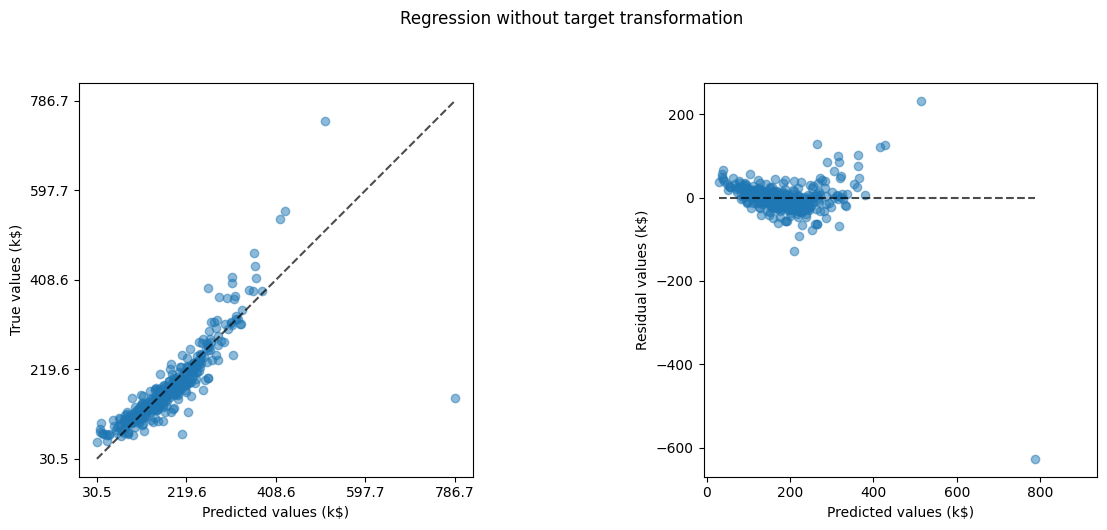

In [5]:
fig, axs = plt.subplots(
    ncols=2,
    figsize=(13, 5),
)

PredictionErrorDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_pred,
    kind="actual_vs_predicted",
    scatter_kwargs={"alpha": 0.5},
    ax=axs[0],
)
axs[0].axis("square")
axs[0].set_xlabel("Predicted values (k$)")
axs[0].set_ylabel("True values (k$)")

PredictionErrorDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_pred,
    kind="residual_vs_predicted",
    scatter_kwargs={"alpha": 0.5},
    ax=axs[1],
)
axs[1].axis("square")
axs[1].set_xlabel("Predicted values (k$)")
axs[1].set_ylabel("Residual values (k$)")

fig.suptitle(
    "Regression without target transformation",
    y=1.05,
)
plt.tight_layout()
plt.show()


## Log scaling: a non-linear target transform

The baseline residual plot hints that **SalePrice** is skewed — a common pattern for prices, incomes, and counts. One way to reshape a skewed target is **log scaling**, a **non-linear** transform that changes the relative spacing between values (unlike min-max or z-score scaling, which are linear).

Log scaling can turn a skewed distribution into a more **symmetric**, approximately normal shape using the natural logarithm:

$$x_\text{normalized} = \ln(x)$$

In code we often use `np.log1p(x)`, which computes $\ln(1 + x)$ and stays safe when $x$ can be 0.

![Effect of transforming the target with a logarithm](https://scikit-learn.org/stable/_images/sphx_glr_plot_transformed_target_001.png)

The log function is the inverse of the exponential function:

![Exponent vs logarithm](../assets/exponent_vs_log.png)

Source: [What is a Logarithm? (MathIsFun)](https://www.mathsisfun.com/algebra/exponents-logarithms.html)

Log scaling is useful for **power-law** data: a few very large values and many small ones.

- **City populations:** ranked by size, the largest city is often about twice the second and three times the third (Zipf's law). In the US, New York City (~8.3M) is roughly twice Los Angeles (~3.8M).
- **Attention:** a few movies or books get most of the attention while the long tail shares the rest.

See [Transforming the target variable](https://scikit-learn.org/stable/auto_examples/compose/plot_transformed_target.html).

### Hypothetical example: video view counts

Before working with the skewed `SalePrice` target, we illustrate log scaling on a simple synthetic column — hypothetical **view counts** for online videos (power-law-like: a few viral hits and many small counts).

In [6]:
# Reproducible skewed counts (power-law-like long tail)
np.random.seed(42)
n_rows = 500

view_count = pd.Series(
    np.clip(
        np.random.lognormal(5, 2.5, size=n_rows).astype(int),
        10,  # floor — every video has at least a few views
        50_000,  # ceiling — cap extreme outliers for illustration
    ),
    name="view_count",
)

view_count_log = np.log1p(view_count)

pd.DataFrame(
    {
        "view_count": view_count,
        "view_count_log": view_count_log,
    }
).round(2).head()

,view_count,view_count_log
0,513,6.24
1,105,4.66
2,749,6.62
3,6684,8.81
4,82,4.42


Comparing the histograms shows the log transform pulling the long right tail into a more symmetric shape.

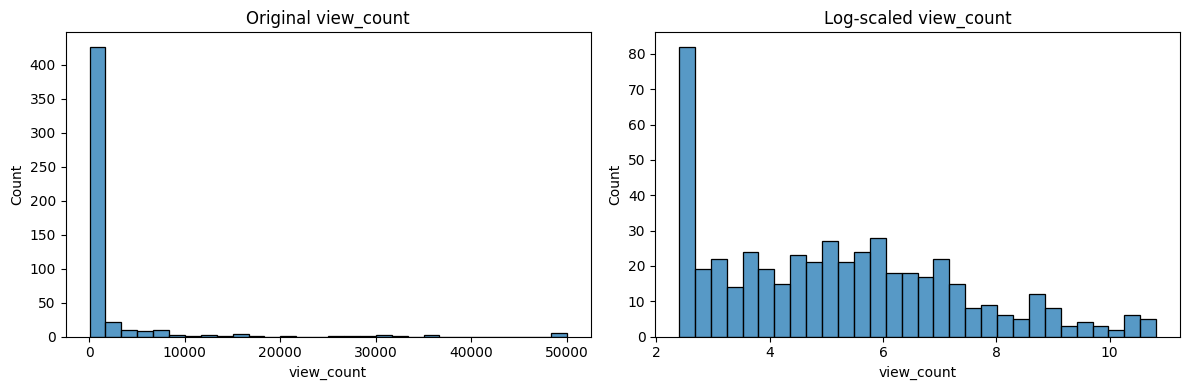

In [7]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 4),
)

sns.histplot(
    data=view_count,
    bins=30,
    ax=axes[0],
)
axes[0].set_title("Original view_count")

sns.histplot(
    data=view_count_log,
    bins=30,
    ax=axes[1],
)
axes[1].set_title("Log-scaled view_count")

fig.tight_layout()
plt.show()

## Target transformation: idea

Strategy:

- Apply a **monotonic transformation** to the target, fit the model in transformed space.
- Transform predictions **back** to the original scale for evaluation.

Tooling: [`QuantileTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.QuantileTransformer.html) wrapped in [`TransformedTargetRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html).


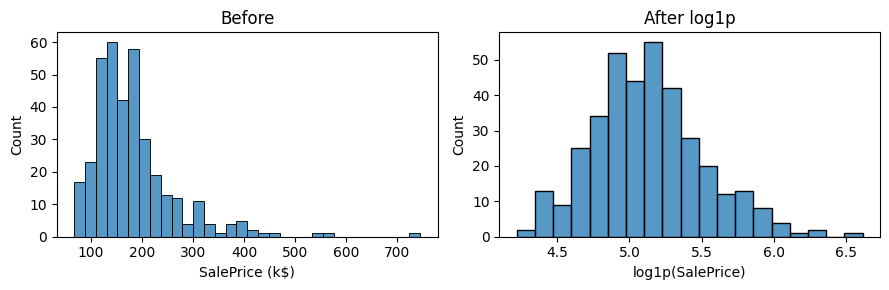

In [8]:
# Log transform as a simple illustration of reshaping a skewed target
y_test_log = np.log1p(y_test)

fig, axs = plt.subplots(
    ncols=2,
    figsize=(9, 3),
)

sns.histplot(
    data=y_test,
    ax=axs[0],
)
axs[0].set_title("Before")
axs[0].set_xlabel("SalePrice (k$)")
axs[0].set_ylabel("Count")

sns.histplot(
    data=y_test_log,
    ax=axs[1],
)
axs[1].set_title("After log1p")
axs[1].set_xlabel("log1p(SalePrice)")
axs[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [9]:
quantile_transformer = QuantileTransformer(
    n_quantiles=900,  # map to 900 quantile bins
    output_distribution="normal",  # reshape toward a Gaussian
    random_state=0,
)

model_quantile_target = TransformedTargetRegressor(
    regressor=LinearRegression(),
    transformer=quantile_transformer,
)

model_quantile_target.fit(
    X=X_train,
    y=y_train,
)


,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",LinearRegression()
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",QuantileTrans...andom_state=0)
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",None
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](34,)","['Id','MSSubClass','LotArea',...,'MiscVal','MoSold','YrSold']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,34
regressor_ regressor_: objectFitted regressor.,LinearRegression,LinearRegression()
transformer_ transformer_: objectTransformer used in :meth:`fit` and :meth:`predict`.,QuantileTransformer,QuantileTrans...andom_state=0)
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True


## After target transformation

Compare prediction and residual plots to the baseline. The banana shape should largely disappear.


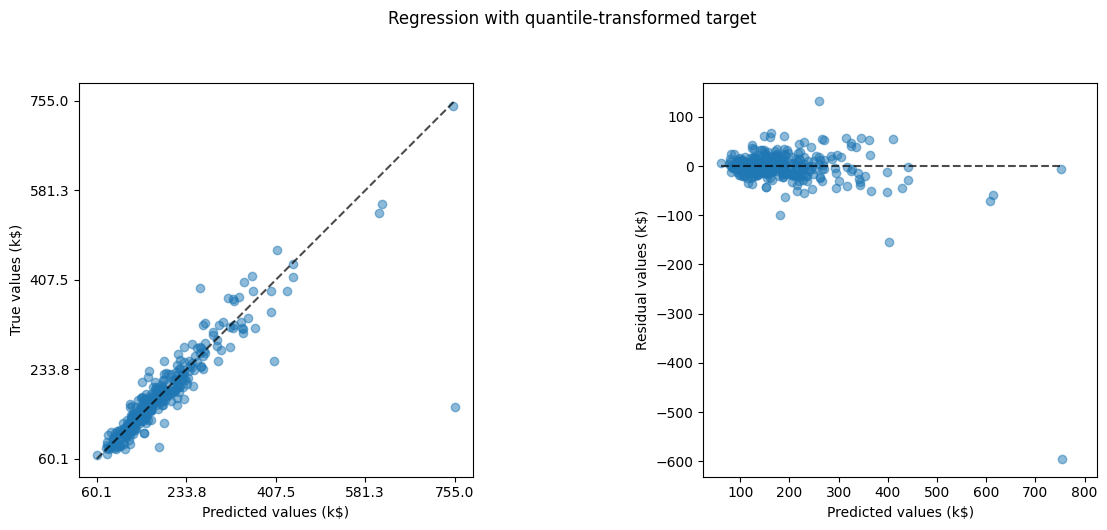

In [10]:
y_pred_transformed = model_quantile_target.predict(X_test)

fig, axs = plt.subplots(
    ncols=2,
    figsize=(13, 5),
)

PredictionErrorDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_pred_transformed,
    kind="actual_vs_predicted",
    scatter_kwargs={"alpha": 0.5},
    ax=axs[0],
)
axs[0].axis("square")
axs[0].set_xlabel("Predicted values (k$)")
axs[0].set_ylabel("True values (k$)")

PredictionErrorDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_pred_transformed,
    kind="residual_vs_predicted",
    scatter_kwargs={"alpha": 0.5},
    ax=axs[1],
)
axs[1].axis("square")
axs[1].set_xlabel("Predicted values (k$)")
axs[1].set_ylabel("Residual values (k$)")

fig.suptitle(
    "Regression with quantile-transformed target",
    y=1.05,
)
plt.tight_layout()
plt.show()


## Metric comparison: before vs after

After target transformation, $R^2$, MAE, median AE, and MAPE should all improve — metrics and plots tell a consistent story.


In [11]:
print("--- Before target transformation ---")
print(f"R² score: {regressor.score(X_test, y_test):.3f}")
print(f"Mean absolute error: {mean_absolute_error(y_test, y_pred):.3f} k$")
print(f"Median absolute error: {median_absolute_error(y_test, y_pred):.3f} k$")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred) * 100:.3f} %")

print()
print("--- After target transformation ---")
print(f"R² score: {model_quantile_target.score(X_test, y_test):.3f}")
print(f"Mean absolute error: {mean_absolute_error(y_test, y_pred_transformed):.3f} k$")
print(f"Median absolute error: {median_absolute_error(y_test, y_pred_transformed):.3f} k$")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_transformed) * 100:.3f} %")


--- Before target transformation ---
R² score: 0.687
Mean absolute error: 22.608 k$
Median absolute error: 14.137 k$
MAPE: 13.574 %

--- After target transformation ---
R² score: 0.769
Mean absolute error: 17.406 k$
Median absolute error: 10.327 k$
MAPE: 9.919 %


### A statistician's note

While common in practice, target transformation for linear regression is sometimes disapproved by statisticians. **It can be more justified to adapt the loss function itself**, for instance with a [`PoissonRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.PoissonRegressor.html) or [`TweedieRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.TweedieRegressor.html), which use an internal log link suited to positive-only targets.

That analysis is beyond the scope of this course — see the linked docstrings for further reading.


## Recap

- Skewed targets can leave structured residuals even when many features are used.
- A monotonic target transformation (`QuantileTransformer` + `TransformedTargetRegressor`) can improve both metrics and diagnostic plots.
- Always cross-check numerical metrics with prediction and residual plots before trusting a transformation.
